In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize
from scipy.optimize import minimize
from helper import *

Solution of Lambert's problem

In [3]:
def stumpS(z): # (3.26)
    if z > 0:
        s = (np.sqrt(z) - np.sin(np.sqrt(z))) / (np.sqrt(z))**3
    elif z < 0:
        s = (np.sinh(np.sqrt(-z,dtype=np.complex128)) - (np.sqrt(-z,dtype=np.complex128))) / (np.sqrt(-z,dtype=np.complex128))**3
    else:
        s = 1/6
    return s

print(stumpS(-40))



(1.078057366222353+0j)


In [4]:
def stumpC(z): # (3.27)
    if z > 0:
        s = (1 - np.cos(np.sqrt(z))) / z
    elif z < 0:
        s = (np.cosh(np.sqrt(-z,dtype=np.complex128)) - 1) / (-z)
    else:
        s = 1/2
    return s

print(stumpC(100))


0.018390715290764525


In [5]:
def y(z,r1,r2,A): # (3.28)
    return r1 + r2 + A*(z*stumpS(z) - 1)/np.sqrt(stumpC(z))

In [6]:
def F(z,t, r1,r2, mu,A): # 3.30
    return ((y(z,r1,r2,A)/stumpC(z))**1.5) * stumpS(z) + A*np.sqrt(y(z,r1,r2,A)) - np.sqrt(mu)*t



In [7]:
def dFdz(z,t,r1,r2,mu,A): # 5.43
    if z == 0:
        result = (np.sqrt(2)/40) * y(0,r1,r2,A)**(1.5) + (A/8)*(np.sqrt(y(0,r1,r2,A)) + A*(np.sqrt(1/(2*y(0,r1,r2,A))))) 
    
    else:
        first_part = (y(z,r1,r2,A)/stumpC(z))**1.5
        second_part = ((1/(2*z)) * (stumpC(z) - (1.5 * (stumpS(z) / stumpC(z)))) + (0.75 * (stumpS(z)**2  / stumpC(z))) )
        third_part = (A/8) * (3* (stumpS(z)/stumpC(z)) * np.sqrt(y(z,r1,r2,A)) + A*(np.sqrt(stumpC(z)/y(z,r1,r2,A))))
        result = first_part*second_part + third_part
    
    return result


In [8]:
# def lambert_solve(R1,R2,t, mu, trajectory_type, debug = False):

#     r1 = np.linalg.norm(R1) # Mag of R1
#     r2 = np.linalg.norm(R2) # Mag of R2

#     cross_r1_r2 = np.cross(R1,R2)
#     theta = np.arccos(np.dot(R1,R2)/(r1*r2))

#     ## Include thing about prograde/retrograde

#     A = np.sin(theta) * np.sqrt((r1*r2) / (1-np.cos(theta)))

#     ## Determine where F(z,t) changes sign. Use value of z as starting value  for 5.45
#     z = -100
#     while F(z,t,r1,r2,mu,A) < 0:
#         z = z + 0.1

#     ## Error Tolerance and max number of iterations
#     tol = 1 * 10**(-8)
#     nmax = 5000

#     # Iterate on 5.45 until z is within error tolerance. Just Newton_Raphson iteration
#     ratio = 1
#     n = 0
#     while (np.abs(ratio) > tol) and (n<=nmax):
#         n = n + 1
#         ratio = F(z,t,r1,r2,mu,A) / dFdz(z,t,r1,r2,mu,A)
#         z = z - ratio

#     if n >= nmax:
#         print(f"\n Numeber of iterations exceeds {nmax}")

#     # Lagrange Coefficients
#     f = 1 - (y(z,r1,r2,A)/r1) # 5.46a
#     g = A*np.sqrt(y(z,r1,r2,A)/mu) # 5.46b
    
#     fdot = (np.sqrt(mu)/(r1*r2)) * (np.sqrt(y(z,r1,r2,A)/stumpC(z)) * (z*stumpS(z) -1)) # 5.46c
#     gdot = 1 - (y(z,r1,r2,A)/r2) # 5.46d


  

#     V1 = (1/g)*(R2 - f*R1)  #5.28
#     V2 = (1/g)*(gdot*R2 - R1)   #5.29

#     if debug:
#         print(f"{r1 = }\t{r2 = }\t{cross_r1_r2 = }\t{A = } \n {V1 = }\t{V2 = }")

#     return V1, V2



# R1 = np.array([5000,10000,2100])
# R2 = np.array([-14600,2500,7000])
# t_of_f = 3600
# lambert_solve(R1,R2, 3600, "Yup", debug = True)

In [77]:
def earth_mars_hohmann_transfer_different(result_str = False):
    mu_sun= 1.327e11 ## km^3/s^2
    mu_earth= 3.986e5 ## km^3/s^2
    mu_mars= 4.2830e4 ## km^3/s^2

    SOI_earth = 923502.24 # km
    SOI_mars = 577723.87 # km

    
    r_mars = 2.279e8
    r_earth = 1.496e8

    r_LEO = 463
    R_LEO = 6378.2 + r_LEO

    r_LMO = 200
    R_LMO = 3397.0 + r_LMO

    a_transfer = (r_mars + r_earth)/2

    v_earth = np.sqrt(mu_sun / r_earth)
    v_inf_depart = (np.sqrt(mu_sun)/r_earth)*(np.sqrt(2-(r_earth/a_transfer)) - 1) 

    a_hyp_depart = ((2/SOI_earth) - ((v_inf_depart**2) / mu_earth))**(-1)
    v_hyp_periapse = np.sqrt(mu_earth * ((2/R_LEO) - (1/a_hyp_depart)))

    delta_v_depart = v_hyp_periapse - np.sqrt(mu_earth/R_LEO)
    print(delta_v_depart)

    v_inf_arrival = (np.sqrt(mu_mars)/r_mars)*(np.sqrt(2-(r_mars/a_transfer)) - 1) 
    a_hyp_arrival = ((2/SOI_mars) - ((v_inf_arrival**2) / mu_mars))**(-1)
    v_hyp_periapse_mars = np.sqrt(mu_mars * ((2/R_LMO) - (1/a_hyp_arrival)))

    delta_v_arrival = (v_hyp_periapse_mars - np.sqrt(mu_mars/R_LMO))
    print(delta_v_arrival)

earth_mars_hohmann_transfer_different(result_str= True)

3.1216869226505732
1.4141000868730513


In [78]:
def earth_mars_hohmann_transfer(result_str = False):
    mu_sun= 1.327e11 ## km^3/s^2
    mu_earth= 3.986e5 ## km^3/s^2
    mu_mars= 4.2830e4 ## km^3/s^2

    SOI_earth = 923502.24 # km
    SOI_mars = 577723.87 # km

    
    r_mars = 2.279e8
    r_earth = 1.496e8

    r_LEO = 463
    R_LEO = 6378.2 + r_LEO

    r_LMO = 200
    R_LMO = 3397.0 + r_LMO

    a_transfer = (r_mars + r_earth)/2


    delta_v1 = np.sqrt(mu_sun/r_earth) * (np.sqrt((2*r_mars)/(r_earth+r_mars)) - 1)

    delta_v2 = np.sqrt(mu_sun/r_mars) * (1 - np.sqrt((2*r_earth)/(r_earth+r_mars)))

    v_p = np.sqrt((delta_v1)**2 + ((2*mu_earth)/R_LEO))

    v_c = np.sqrt(mu_earth/R_LEO)
    delta_v_Earth = v_p - v_c
    delta_v_inf = np.sqrt(mu_sun/r_mars)*(1 - np.sqrt((2*r_earth)/(r_earth + r_mars)))
    delta_v_mars = np.sqrt(delta_v_inf**2 + (2*mu_mars/R_LMO)) - np.sqrt(mu_mars*(1)/R_LMO)

    delta_v_total = delta_v_Earth + delta_v_mars


    t_of_f = np.pi * np.sqrt(((r_mars + r_earth)**3)/(8*mu_sun))
    t_of_f_days = t_of_f/(60*60*24)

    
    

    if result_str:
        print(f"""
Delta V_Leo = {delta_v_Earth}
Delta V_LMO = {delta_v_mars}
Delta V_Total = {delta_v_total}

Time of Flight = {t_of_f_days:.2f} Days
Semi-major axis = {a_transfer:e} Km
""")

    return delta_v_total

earth_mars_hohmann_transfer(result_str= True)



Delta V_Leo = 3.5558147563670417
Delta V_LMO = 2.101362221346033
Delta V_Total = 5.657176977713075

Time of Flight = 258.84 Days
Semi-major axis = 1.887500e+08 Km



np.float64(5.657176977713075)

In [10]:
def lambert_solve(R1,R2,t,mu, trajectory_type, debug = False):
    # t in days
    t = t* (60*60*24) # convert to seconds


    r1 = np.linalg.norm(R1) # Mag of R1
    r2 = np.linalg.norm(R2) # Mag of R2

    cross_r1_r2 = np.cross(R1,R2) # cross product if R1 and R2

    if trajectory_type == "pro": # (3.23)
        if cross_r1_r2[2] >= 0:
            theta = np.arccos(np.dot(R1,R2)/(r1*r2))
        
        else:
            theta = 2*np.pi - np.arccos(np.dot(R1,R2)/(r1*r2))

    elif trajectory_type == "retro": # (3.24)
        if cross_r1_r2[2] < 0:
            theta = np.arccos(np.dot(R1,R2)/(r1*r2))
        
        else:
            theta = 2*np.pi - np.arccos(np.dot(R1,R2)/(r1*r2))

    else:
        print("Trajectory type not specified")
        return

    # print(np.rad2deg(theta))
    # if np.rad2deg(theta) == 180.0:
    #     print("180deg anomaly => Hohmann Transfer")
    #     print(f"{earth_mars_hohmann_transfer()}")
    #     return earth_mars_hohmann_transfer() 
    A = np.sin(theta) * np.sqrt((r1*r2) / (1-np.cos(theta))) # (3.25)

    ## Determine where approximately F(z) changes sign. This will be used as an initial guess for root-finding.
    z = -100
    while F(z,t,r1,r2,mu,A) < 0:
        z = z + 0.1


    ## Error Tolerance and max number of iterations
    tol = 1 * 10**(-8)
    nmax = 5000

    # Apply Newton-Raphson root-finder from scipy library
    z = optimize.newton(F,z,tol = tol, maxiter = nmax, args = (t,r1,r2,mu,A)) 


    # Lagrange Coefficients
    f = 1 - (y(z,r1,r2,A)/r1) # (3.31)
    g = A*np.sqrt(y(z,r1,r2,A)/mu) # (3.32)

    
    fdot = (np.sqrt(mu)/(r1*r2)) * (np.sqrt(y(z,r1,r2,A)/stumpC(z)) * (z*stumpS(z) -1)) # (3.33)
    gdot = 1 - (y(z,r1,r2,A)/r2) # (3.34)
    
    if debug:
        print(f"{g = } {R2 = } {f = } {R1 = }")
    V1 = (1/g)*(R2 - f*R1) # (3.35)
    
    V2 = (1/g)*(gdot*R2 - R1) # (3.36)

    if debug:
        print(f"{r1 = }\t{r2 = }\t{cross_r1_r2 = }\t{A = } \n {V1 = }\t{V2 = }")

    return V1, V2


mu_sun = 1.327e11  # Suns gravitational parameter in (km^3/s^2) 

R1 = np.array([1.4762e+08 ,0.0000e+00 ,0.0000e+00])
R2 = np.array([-2.2800000e+08 , 2.7921947e-08 , 0.0000000e+00])
t_of_f = 60*60*24 * 270
lambert_solve(R1,R2, t_of_f, mu_sun, "pro", debug = True)

g = np.float64(8.452297419925728e-10) R2 = array([-2.2800000e+08,  2.7921947e-08,  0.0000000e+00]) f = np.float64(-1.544506164476358) R1 = array([1.4762e+08, 0.0000e+00, 0.0000e+00])
r1 = np.float64(147620000.0)	r2 = np.float64(228000000.0)	cross_r1_r2 = array([ 0.        , -0.        ,  4.12183782])	A = np.float64(1.588677986858443e-08) 
 V1 = array([-35.2594341 ,  33.03474264,   0.        ])	V2 = array([  0.        , -21.38854697,  -0.        ])


(array([-35.2594341 ,  33.03474264,   0.        ]),
 array([  0.        , -21.38854697,  -0.        ]))

EARTH-TO-MARS Hohmann Transfer Trajectory

In [11]:
mu_sun= 1.327e11 ## km^3/s^2
mu_earth= 3.986e5 ## km^3/s^2
mu_mars= 4.28284e4 ## km^3/s^2


r_mars = 2.279e8
r_earth = 1.496e8

r_LEO = 463
R_LEO = 6371 + r_LEO

r_LMO = 200
R_LMO = 3397 + r_LMO



In [12]:
delta_v1 = np.sqrt(mu_sun/r_earth) * (np.sqrt((2*r_mars)/(r_earth+r_mars)) - 1)

delta_v2 = np.sqrt(mu_sun/r_mars) * (1 - np.sqrt((2*r_earth)/(r_earth+r_mars)))

In [13]:
print(delta_v1, delta_v2)

2.9433246203696513 2.6477927644362698


In [14]:
v_p = np.sqrt((delta_v1)**2 + ((2*mu_earth)/R_LEO))

v_c = np.sqrt(mu_earth/R_LEO)
print(v_p, v_c)

11.194426906670197 7.637147175087944


In [15]:
delta_v_Earth = v_p - v_c
print(delta_v_Earth) # delta v required to leave LEO

3.557279731582253


In [16]:
delta_v_inf = np.sqrt(mu_sun/r_mars)*(1 - np.sqrt((2*r_earth)/(r_earth + r_mars)))
print(delta_v_inf)

2.6477927644362698


In [17]:
print(np.sqrt(mu_mars/R_LMO))

3.4506086459928986


In [18]:
delta_v_mars = np.sqrt(delta_v_inf**2 + (2*mu_mars/R_LMO)) - np.sqrt(mu_mars*(1)/R_LMO)

print(delta_v_mars) # delta v required to enter LMO

2.101346557266846


In [19]:
delta_v_total = delta_v_Earth + delta_v_mars
delta_v_total

np.float64(5.658626288849099)

### Time of flight calculation

In [49]:
t_of_f = np.pi * np.sqrt(((r_mars + r_earth)**3)/(8*mu_sun))
print(t_of_f/(60*60*24))



256.90865638743503


### Initial Alignment Required

In [21]:
ang_vel_mars = np.sqrt(mu_sun/(r_mars**3))

In [22]:
alpha = np.pi - ang_vel_mars*t_of_f
print(np.rad2deg(alpha))

44.329177537579916


In [23]:
theta = np.linspace(0, 2*np.pi, 300)
x_earth_orbit = [r_earth*np.cos(t) for t in theta]
y_earth_orbit = [r_earth*np.sin(t) for t in theta]

x_mars_orbit = [r_mars*np.cos(t) for t in theta]
y_mars_orbit = [r_mars*np.sin(t) for t in theta]



In [24]:
v_spacecraft_departure = np.sqrt(2*mu_sun) * np.sqrt((r_mars)/ (r_earth*(r_earth+r_mars)))

v_spacecraft_arrival= np.sqrt(2*mu_sun) * np.sqrt((r_earth)/ (r_mars*(r_earth+r_mars)))

print(v_spacecraft_arrival, v_spacecraft_departure)

21.48253932449791 32.726408503028566


In [25]:
e_transfer = (r_mars - r_earth)/(r_mars + r_earth)
print(e_transfer)

h = np.sqrt(2*mu_sun) * np.sqrt((r_earth*r_mars)/(r_earth+r_mars))
print(h)

a = (r_mars + r_earth)/2
print(a)

b = a* np.sqrt(1 - e_transfer**2)
print(b)

0.20741721854304634
4895870712.053073
188750000.0
184645173.2377535


In [26]:
theta = np.linspace(0, 180, 150)
r_transfer = [orbit_eqn(h,e_transfer,t,mu_sun) for t in theta]
print(r_transfer)
x_transfer = r_transfer*np.cos(np.radians(theta)) 
y_transfer = r_transfer * np.sin(np.radians(theta))



[np.float64(149599999.99999997), np.float64(149605712.37541622), np.float64(149622849.57938382), np.float64(149651411.84336737), np.float64(149691399.5475022), np.float64(149742813.21212846), np.float64(149805653.48592663), np.float64(149879921.13063958), np.float64(149965617.00236607), np.float64(150062742.02940387), np.float64(150171297.18661878), np.float64(150291283.46631226), np.float64(150422701.8455559), np.float64(150565553.24995834), np.float64(150719838.5138269), np.float64(150885558.3366827), np.float64(151062713.2360851), np.float64(151251303.49671784), np.float64(151451329.11568785), np.float64(151662789.74398285), np.float64(151885684.62403366), np.float64(152120012.5233225), np.float64(152365771.66397938), np.float64(152622959.64830288), np.float64(152891573.3801446), np.float64(153171608.98209047), np.float64(153463061.7083754), np.float64(153765925.85346323), np.float64(154080194.6562264), np.float64(154405860.19965792), np.float64(154742913.30604887), np.float64(15509

In [27]:
r_mars = orbit_eqn(h,e_transfer,180,mu_sun)
x_mars = r_mars*np.cos(np.radians(180)) 
y_mars = r_mars * np.sin(np.radians(180))

r_earth = orbit_eqn(h,e_transfer,0,mu_sun)
x_earth = r_earth*np.cos(np.radians(0))
y_earth = r_earth * np.sin(np.radians(0))





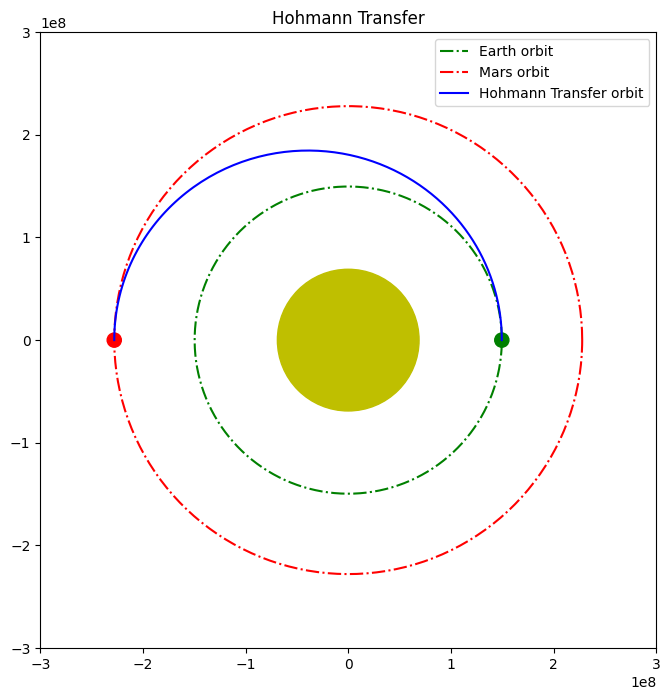

In [28]:
fig, ax = plt.subplots(figsize = (13,8))
ax.set_aspect(1)

plt.xlim(-3e8,+3e8)
plt.ylim(-3e8,+3e8)

plt.plot(x_earth_orbit,y_earth_orbit, "g-.", label = "Earth orbit")
plt.plot(x_mars_orbit,y_mars_orbit, "r-.", label = "Mars orbit")

plt.plot(x_transfer, y_transfer, "b",label = "Hohmann Transfer orbit")
sun = plt.Circle((0,0), 6.9e7, color = "y")
ax.add_patch(sun)

mars = plt.Circle((x_mars,y_mars), 6.9e6, color = "r")
ax.add_patch(mars)

earth = plt.Circle((x_earth,y_earth), 6.9e6, color = "g")
ax.add_patch(earth)

plt.legend()
plt.title("Hohmann Transfer")
plt.show()

## Lambert Earth-Mars Transfer

In [29]:
R_earth = 147.62e6 # km, average distance from sun
h_earth = np.sqrt(R_earth * mu_sun) # circular orbit
earth_orbit = Orbit(h_earth,0,0,0,0,0) # circular orbit

R1, V1 = calculate_state_vector_from_orbit(earth_orbit,mu_sun,debug= False)
print(R1,V1)

[1.4762e+08 0.0000e+00 0.0000e+00] [ 0.        29.9821561  0.       ]


In [30]:
R_mars = 228e6 # km, average distance from sun
h_mars = np.sqrt(R_mars * mu_sun)
mars_orbit = Orbit(h_mars,0,0,0,0,179) # Weird Vd calculated at 180 deg. 

R2, V2 = calculate_state_vector_from_orbit(mars_orbit,mu_sun,debug=False)
print(R2,V2)

[-2.27965274e+08  3.97914867e+06  0.00000000e+00] [ -0.42104    -24.12136541   0.        ]


In [31]:
t_of_f = 60*60*24 * 264 # Days Filho and Fernandes optimized for

Vd, Va = lambert_solve(np.array(R1),np.array(R2),t_of_f,mu_sun,"pro", debug = True)

print(Vd,Va)
print(np.linalg.norm(Vd))



g = np.float64(120970.15527259985) R2 = array([-2.27965274e+08,  3.97914867e+06,  0.00000000e+00]) f = np.float64(-1.566187794662906) R1 = array([1.4762e+08, 0.0000e+00, 0.0000e+00])
r1 = np.float64(147620000.0)	r2 = np.float64(228000000.0)	cross_r1_r2 = array([ 0.00000000e+00, -0.00000000e+00,  5.87401926e+14])	A = np.float64(2264106.65629574) 
 V1 = array([26.74517318, 32.89363942,  0.        ])	V2 = array([ 26.26822729, -21.75894659,  -0.        ])
[26.74517318 32.89363942  0.        ] [ 26.26822729 -21.75894659  -0.        ]
42.39452561994187


In [32]:
v_inf_d = Vd - V1
print(v_inf_d, np.linalg.norm(v_inf_d))

v_inf_a = Va - V2
print(v_inf_a, np.linalg.norm(v_inf_a))


[26.74517318  2.91148332  0.        ] 26.90317868922549
[26.68926729  2.36241882 -0.        ] 26.793618849019843


In [33]:
transfer_orbit = calculate_orbit_from_state_vector(R1,Vd,mu_sun)



        r = array([1.4762e+08, 0.0000e+00, 0.0000e+00])
        mag_r = np.float64(147620000.0)
        v = array([26.74517318, 32.89363942,  0.        ])
        mag_v = np.float64(42.39452561994187)
        radial_v = np.float64(26.745173180857904)
        h = array([0.00000000e+00, 0.00000000e+00, 4.85575905e+09])
        i = np.float64(0.0)
        RA = np.float64(nan)
        e = np.float64(0.9996226283796316)
        w = np.float64(nan)
        theta = np.float64(78.24535668793503)


f:\project\orbital_trajectories\helper.py:118: RuntimeWarning: invalid value encountered in scalar divide
  RA = np.degrees(np.arccos(node_line[0]/mag_node_line))
f:\project\orbital_trajectories\helper.py:127: RuntimeWarning: invalid value encountered in scalar divide
  w = np.degrees(np.arccos((np.dot(node_line,e_vector)/(mag_node_line*e))))


In [34]:
theta = np.linspace(0, 180, 100)
r_transfer = [orbit_eqn(transfer_orbit.h,transfer_orbit.e,t,mu_sun) for t in theta]
print(r_transfer)
x_transfer = r_transfer*np.cos(np.radians(theta)) 
y_transfer = r_transfer * np.sin(np.radians(theta))


r_mars = orbit_eqn(mars_orbit.h,mars_orbit.e,180,mu_sun)
x_mars = r_mars*np.cos(np.radians(180)) 
y_mars = r_mars * np.sin(np.radians(180))

r_earth = orbit_eqn(earth_orbit.h,earth_orbit.e,0,mu_sun)
x_earth = r_earth*np.cos(np.radians(0))
y_earth = r_earth * np.sin(np.radians(0))

[np.float64(88857745.69148067), np.float64(88880115.15456596), np.float64(88947268.60772459), np.float64(89059341.43566976), np.float64(89216559.92435955), np.float64(89419242.23313595), np.float64(89667799.76574686), np.float64(89962738.95041405), np.float64(90304663.44221032), np.float64(90694276.76426029), np.float64(91132385.40772127), np.float64(91619902.4141737), np.float64(92157851.46800224), np.float64(92747371.5306264), np.float64(93389722.05310187), np.float64(94086288.80872168), np.float64(94838590.39286977), np.float64(95648285.44359851), np.float64(96517180.6433077), np.float64(97447239.56959473), np.float64(98440592.4719471), np.float64(99499547.06058922), np.float64(100626600.40463573), np.float64(101824452.04892088), np.float64(103096018.47267683), np.float64(104444449.02886495), np.float64(105873143.52070653), np.float64(107385771.59213722), np.float64(108986294.13191071), np.float64(110678986.9173497), np.float64(112468466.7538121), np.float64(114359720.40043367), np.

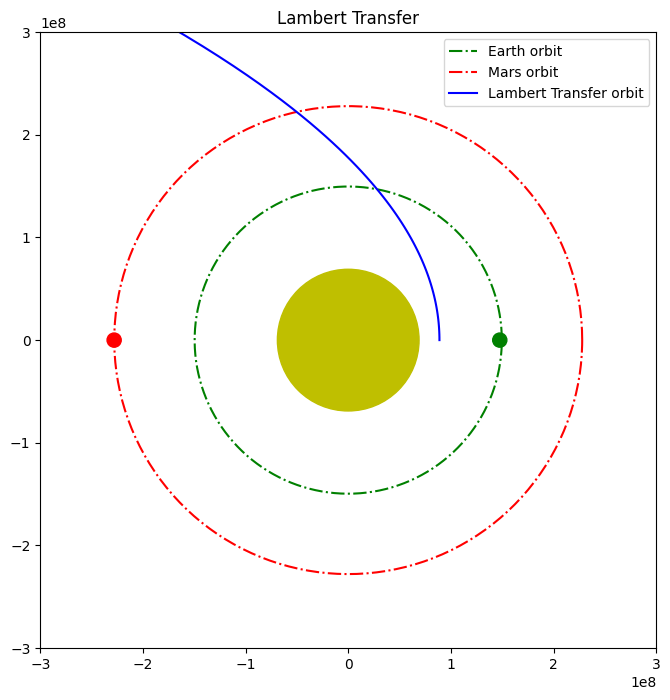

In [35]:
fig, ax = plt.subplots(figsize = (13,8))
ax.set_aspect(1)


plt.xlim(-3e8,+3e8)
plt.ylim(-3e8,+3e8)

plt.plot(x_earth_orbit,y_earth_orbit, "g-.", label = "Earth orbit")
plt.plot(x_mars_orbit,y_mars_orbit, "r-.", label = "Mars orbit")

plt.plot(x_transfer, y_transfer, "b",label = "Lambert Transfer orbit")
sun = plt.Circle((0,0), 6.9e7, color = "y")
ax.add_patch(sun)

mars = plt.Circle((x_mars,y_mars), 6.9e6, color = "r")
ax.add_patch(mars)

earth = plt.Circle((x_earth,y_earth), 6.9e6, color = "g")
ax.add_patch(earth)

plt.legend()
plt.title("Lambert Transfer")
plt.show()

### Lambert Departure

In [36]:
r_LEO = 6371 + 463
v_inf_d_mag = np.linalg.norm(v_inf_d)
v_periapse = np.sqrt((v_inf_d_mag**2) + (2*mu_earth/r_LEO))
v_o = np.sqrt(mu_earth/r_LEO)

delta_v1 = v_periapse - v_o
print(delta_v1)

21.353076306843068


### Lambert Arrival

In [37]:
r_LMO = 3397 + 200
v_inf_a_mag = np.linalg.norm(v_inf_a)
v_periapse = np.sqrt((v_inf_a_mag**2) + (2*mu_mars/r_LMO))
v_o = np.sqrt(mu_mars/r_LMO)

delta_v2 = v_periapse - v_o
print(delta_v2)

23.783770566358417


In [38]:
delta_total = delta_v1 + delta_v2
print(delta_total)

45.136846873201485


In [39]:
def simulate(anomaly, t_of_f):
    if anomaly == 180:
        return earth_mars_hohmann_transfer()
    R_earth = 147.62e6 # km, average distance from sun
    h_earth = np.sqrt(R_earth * mu_sun) # circular orbit
    earth_orbit = Orbit(h_earth,0,0,0,0,0) # circular orbit

    R1, V1 = calculate_state_vector_from_orbit(earth_orbit,mu_sun,debug= False)

    R_mars = 228e6 # km, average distance from sun
    h_mars = np.sqrt(R_mars * mu_sun)
    mars_orbit = Orbit(h_mars,0,0,0,0,anomaly) # Weird Vd calculated at 180 deg. 

    R2, V2 = calculate_state_vector_from_orbit(mars_orbit,mu_sun,debug=False)
    # print(f"{R2} {V2}")

    Vd, Va = lambert_solve(np.array(R1),np.array(R2),t_of_f,mu_sun,"pro", debug = False)
    # print(f"{Vd = } {Va = }")
    v_inf_d = Vd - V1
    v_inf_a = Va - V2
    # print(f"{v_inf_d = } {v_inf_a = }")

    r_LEO = 6371 + 463
    v_inf_d_mag = np.linalg.norm(v_inf_d)
    v_periapse = np.sqrt((v_inf_d_mag**2) + (2*mu_earth/r_LEO))
    v_o = np.sqrt(mu_earth/r_LEO)

    delta_v1 = v_periapse - v_o

    r_LMO = 3397 + 200
    v_inf_a_mag = np.linalg.norm(v_inf_a)
    v_periapse = np.sqrt((v_inf_a_mag**2) + (2*mu_mars/r_LMO))
    v_o = np.sqrt(mu_mars/r_LMO)

    delta_v2 = v_periapse - v_o
    delta_total = delta_v1 + delta_v2
    return delta_total

simulate(182.429,264.43*(60*60*24))

np.float64(44.358025190709135)

In [40]:
simulate(183,264.43*(60*60*24))

np.float64(44.22854359664281)

In [41]:
initial_guess = [170,200*(60*60*24)]

def wrapped_simulate(x):
    anomaly, t_of_f = x
    return simulate(anomaly, t_of_f)

optimized = minimize(wrapped_simulate,initial_guess, bounds=((1,360),(200,300)))
print(f"optimized angle = {optimized.x[0]} degrees    \noptimized time = {optimized.x[1]} days")

optimized angle = 179.6959328459689 degrees    
optimized time = 256.3378210593418 days


In [42]:
optimized.x[1]

np.float64(256.3378210593418)